# Stretch Offline ESDF OMPL Path Tuning

Use the offline ESDF from `stretch_esdf_offline.yaml` with the current `OMPLBasePlanner` task from `stretch_esdf_online_nvblox_ompl_wbmpc.yaml`. Edit the start, goal, planner, and clearance knobs below, then rerun the planning and visualization cells.

In [348]:
from pathlib import Path
import copy
import os
import sys

import numpy as np
import yaml

ROOT = Path.cwd().resolve()
if not (ROOT / "mm_run").exists():
    ROOT = ROOT.parent

os.environ.setdefault("MPLCONFIGDIR", "/tmp/mobile_manipulation_matplotlib")

for rel in ("mm_plan/src", "mm_control/src", "mm_utils/src"):
    path = str(ROOT / rel)
    if path not in sys.path:
        sys.path.insert(0, path)

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.collections import LineCollection

from mm_control.esdf_map import ESDFMap
from mm_plan.ompl_base_planner import OMPLBasePlanner

np.set_printoptions(precision=3, suppress=True)
ROOT

PosixPath('/home/tueilsy-st-011/repo/mobile_manipulation')

## Load Configs And ESDF

The ESDF map path comes from `stretch_esdf_offline.yaml`. The planner task comes from the first `OMPLBasePlanner` task in `stretch_esdf_online_nvblox_ompl_wbmpc.yaml`.

In [349]:
OFFLINE_CONFIG_PATH = ROOT / "mm_run/config/stretch_esdf_offline.yaml"
PLANNER_CONFIG_PATH = ROOT / "mm_run/config/stretch_esdf_online_nvblox_ompl_wbmpc.yaml"

with OFFLINE_CONFIG_PATH.open() as f:
    offline_config = yaml.safe_load(f)
with PLANNER_CONFIG_PATH.open() as f:
    planner_config = yaml.safe_load(f)

def resolve_package_path(spec):
    return ROOT / spec["package"] / spec["path"]

offline_esdf_config = offline_config["controller"]["esdf_collision"]
map_path = resolve_package_path(offline_esdf_config["map_path"])
require_all_corners_valid = offline_esdf_config.get(
    "require_all_corners_valid", True
)

ompl_task_template = next(
    task
    for task in planner_config["planner"]["tasks"]
    if task.get("planner_type") == "OMPLBasePlanner"
)

esdf_map = ESDFMap(
    map_path,
    require_all_corners_valid=require_all_corners_valid,
)

print(f"ESDF: {map_path}")
print(f"shape: {esdf_map.distance.shape}, resolution: {esdf_map.resolution}")
print(f"bounds: {esdf_map.bounds}")
print(f"valid voxels: {np.count_nonzero(esdf_map.valid):,} / {esdf_map.valid.size:,}")
print(f"template goal: {ompl_task_template['base_pose']}")

ESDF: /home/tueilsy-st-011/repo/mobile_manipulation/mm_run/results/nvblox_esdf/esdf_test_room_full_2cm_dense/2026-06-15_12-32-10/esdf_grid.npz
shape: (421, 421, 101), resolution: [0.02 0.02 0.02]
bounds: [-4.2 -4.2  0.   4.2  4.2  2. ]
valid voxels: 17,901,341 / 17,901,341
template goal: [2.0, -2.0, 0.0]


## Tuning Knobs

Change these values and rerun cells below. `d_safe` and `base_radius` are the most important clearance knobs for the base path. `range` controls the RRT branch length.

In [350]:
START = np.array([0.0, 0.0, 0.0], dtype=float)
GOAL = np.array([2.0, -2.0, 0.0], dtype=float)

PLANNER_NAME = "BITstar"  # Try: RRTConnect, RRTstar, BITstar, PRM
SOLVE_TIME = 0.5
SIMPLIFY = True
SIMPLIFY_TIME = 0.05
RANGE = 0.10
GOAL_TOLERANCE = 0.08
STATE_VALIDITY_RESOLUTION = 0.01

BASE_RADIUS = 0.25
D_SAFE = 0.1
QUERY_Z = [0.15, 0.35]
UNKNOWN_IS_VALID = False  # Offline ESDF should usually be strict.

LINEAR_SPEED = 0.25
ANGULAR_SPEED = 0.8
INTERPOLATION_RESOLUTION = 0.05

task_config = copy.deepcopy(ompl_task_template)
task_config["base_pose"] = GOAL.tolist()
task_config["ompl"] = {
    **task_config.get("ompl", {}),
    "planner": PLANNER_NAME,
    "solve_time": SOLVE_TIME,
    "simplify": SIMPLIFY,
    "simplify_time": SIMPLIFY_TIME,
    "range": RANGE,
    "goal_tolerance": GOAL_TOLERANCE,
    "state_validity_resolution": STATE_VALIDITY_RESOLUTION,
}
task_config["path"] = {
    **task_config.get("path", {}),
    "linear_speed": LINEAR_SPEED,
    "angular_speed": ANGULAR_SPEED,
    "interpolation_resolution": INTERPOLATION_RESOLUTION,
    "yaw_mode": "tangent",
}
task_config["esdf"] = {
    **task_config.get("esdf", {}),
    "enabled": True,
    "base_radius": BASE_RADIUS,
    "d_safe": D_SAFE,
    "query_z": QUERY_Z,
    "unknown_is_valid": UNKNOWN_IS_VALID,
    "allow_straight_line_fallback": False,
}
task_config["replan"] = {
    **task_config.get("replan", {}),
    "enabled": False,
}

task_config

{'name': 'OMPL Base To Work Area',
 'planner_type': 'OMPLBasePlanner',
 'base_pose': [2.0, -2.0, 0.0],
 'base_mask': [True, True, True],
 'bounds_xy': [[-4.0, 4.0], [-4.0, 4.0]],
 'bounds_margin': 0.75,
 'tracking_pos_err_tol': 0.15,
 'tracking_ori_err_tol': 0.25,
 'end_stop': False,
 'ompl': {'planner': 'BITstar',
  'solve_time': 0.5,
  'simplify': True,
  'simplify_time': 0.05,
  'range': 0.1,
  'goal_tolerance': 0.08,
  'state_validity_resolution': 0.01},
 'path': {'dt': 0.1,
  'linear_speed': 0.25,
  'angular_speed': 0.8,
  'interpolation_resolution': 0.05,
  'yaw_mode': 'tangent'},
 'esdf': {'enabled': True,
  'base_radius': 0.25,
  'd_safe': 0.1,
  'query_z': [0.15, 0.35],
  'unknown_is_valid': False,
  'allow_straight_line_fallback': False},
 'replan': {'enabled': False,
  'validate_every_step': True,
  'validate_remaining_path': True,
  'min_interval': 1.0,
  'check_horizon': 2.0,
  'check_dt': 0.2,
  'min_clearance': 0.02,
  'deviation_threshold': 0.4,
  'force_periodic': Fals

## Plan With The Current Planner

This directly instantiates `OMPLBasePlanner` and gives it the offline `ESDFMap`. No simulator or MPC is started.

In [351]:
def make_robot_states(base_pose, dof=11):
    q = np.zeros(dof, dtype=float)
    v = np.zeros(dof, dtype=float)
    q[:3] = np.asarray(base_pose, dtype=float)
    return q, v

def path_length_xy(path):
    if len(path) < 2:
        return 0.0
    return float(np.linalg.norm(np.diff(path[:, :2], axis=0), axis=1).sum())

def path_clearance(planner, path):
    return np.array([planner._state_clearance(state) for state in path], dtype=float)

def plan_once(task_cfg, start):
    planner = OMPLBasePlanner(task_cfg, resources={"esdf_map": esdf_map})
    planner.activate()
    planner.updatePlanningContext(0.0, make_robot_states(start), num_pts=21, dt=0.1)
    path = planner.base_plan["p"].copy()
    times = planner.base_plan["t"].copy()
    velocities = planner.base_plan["v"].copy()
    clearances = path_clearance(planner, path)
    return planner, path, times, velocities, clearances

planner, path, times, velocities, clearances = plan_once(task_config, START)

print(f"start: {path[0]}")
print(f"goal:  {path[-1]}")
print(f"points: {len(path)}")
print(f"xy length: {path_length_xy(path):.3f} m")
print(f"duration: {times[-1]:.3f} s")
print(
    "clearance min/p10/median: "
    f"{np.nanmin(clearances):.3f} / "
    f"{np.nanpercentile(clearances, 10):.3f} / "
    f"{np.nanmedian(clearances):.3f} m"
)

Info:    kBITstar: No optimization objective specified. Defaulting to optimizing path length.
Info:    kBITstar: Searching for a solution to the given planning problem.
Info:    kBITstar (6 iters): Found a solution of cost 3.6180 (3 vertices) from 84 samples by processing 5 edges (5 collision checked) to create 4 vertices and perform 0 rewirings. The graph currently has 4 vertices.
Info:    kBITstar: Pruning disconnected 0 vertices from the tree and completely removed 82 samples.
Info:    kBITstar: Pruning disconnected 0 vertices from the tree and completely removed 83 samples.
Info:    kBITstar: Pruning disconnected 0 vertices from the tree and completely removed 91 samples.
Info:    kBITstar: Pruning disconnected 0 vertices from the tree and completely removed 89 samples.
Info:    kBITstar: Pruning disconnected 0 vertices from the tree and completely removed 90 samples.
Info:    kBITstar: Pruning disconnected 0 vertices from the tree and completely removed 86 samples.
Info:    kBITst

## Visualize Projected Base Clearance

The plot projects the 3D ESDF over `QUERY_Z`, subtracts `BASE_RADIUS + D_SAFE`, and overlays the planned path. Red means the base footprint is invalid for these planner settings.

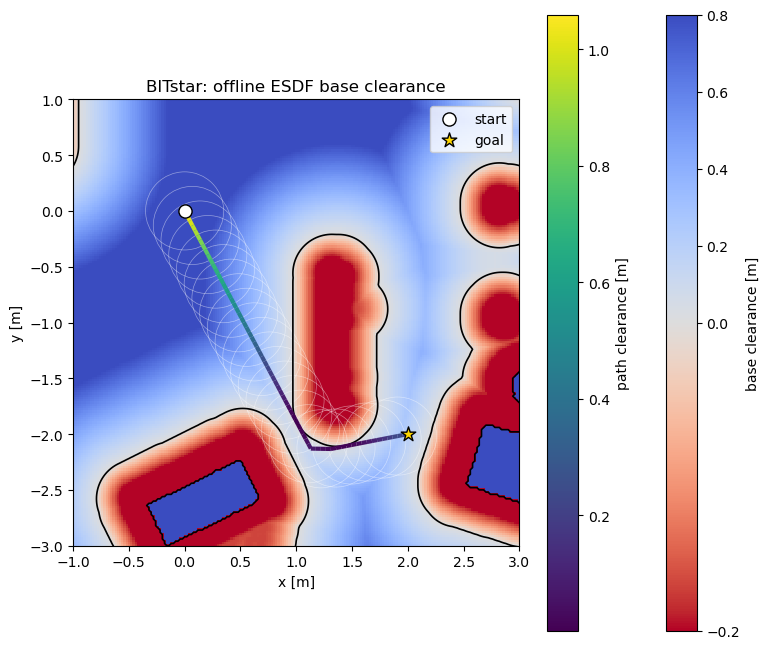

In [352]:
def projected_base_clearance(esdf, z_values, base_radius, d_safe):
    z_values = np.asarray(z_values, dtype=float)
    z_min = float(np.min(z_values)) - 1.0e-9
    z_max = float(np.max(z_values)) + 1.0e-9
    z_mask = (esdf.zs >= z_min) & (esdf.zs <= z_max)
    if not np.any(z_mask):
        nearest = int(np.argmin(np.abs(esdf.zs - float(np.mean(z_values)))))
        z_mask[nearest] = True
    valid_band = esdf.valid[:, :, z_mask]
    distances = esdf.distance[:, :, z_mask]
    projected_distance = np.min(
        np.where(valid_band, distances, np.inf),
        axis=2,
    )
    projected_valid = np.any(valid_band, axis=2) & np.isfinite(projected_distance)
    clearance = projected_distance - float(base_radius) - float(d_safe)
    clearance[~projected_valid] = np.nan
    return clearance, projected_valid

def line_segments_xy(points):
    xy = points[:, :2]
    return np.stack([xy[:-1], xy[1:]], axis=1)

clearance_grid, valid_grid = projected_base_clearance(
    esdf_map,
    QUERY_Z,
    BASE_RADIUS,
    D_SAFE,
)

fig, ax = plt.subplots(figsize=(9, 8))
masked = np.ma.masked_invalid(clearance_grid.T)
norm = TwoSlopeNorm(vmin=-0.20, vcenter=0.0, vmax=0.80)
im = ax.imshow(
    masked,
    extent=[esdf_map.xs[0], esdf_map.xs[-1], esdf_map.ys[0], esdf_map.ys[-1]],
    origin="lower",
    cmap="coolwarm_r",
    norm=norm,
    interpolation="nearest",
)
fig.colorbar(im, ax=ax, label="base clearance [m]")

levels = [0.0]
ax.contour(
    esdf_map.xs,
    esdf_map.ys,
    np.nan_to_num(clearance_grid.T, nan=-1.0),
    levels=levels,
    colors="black",
    linewidths=1.2,
)

if len(path) > 1:
    segment_values = 0.5 * (clearances[:-1] + clearances[1:])
    lc = LineCollection(
        line_segments_xy(path),
        array=segment_values,
        cmap="viridis",
        linewidth=3.0,
    )
    ax.add_collection(lc)
    fig.colorbar(lc, ax=ax, label="path clearance [m]")

ax.scatter(START[0], START[1], s=90, marker="o", c="white", edgecolors="black", label="start", zorder=5)
ax.scatter(GOAL[0], GOAL[1], s=120, marker="*", c="gold", edgecolors="black", label="goal", zorder=5)

stride = max(1, len(path) // 20)
for p in path[::stride]:
    circle = plt.Circle(
        (p[0], p[1]),
        BASE_RADIUS + D_SAFE,
        color="white",
        fill=False,
        linewidth=0.5,
        alpha=0.45,
    )
    ax.add_patch(circle)

ax.set_aspect("equal", adjustable="box")
ax.set_xlim(min(START[0], GOAL[0]) - 1.0, max(START[0], GOAL[0]) + 1.0)
ax.set_ylim(min(START[1], GOAL[1]) - 1.0, max(START[1], GOAL[1]) + 1.0)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title(f"{PLANNER_NAME}: offline ESDF base clearance")
ax.legend(loc="upper right")
plt.show()

## Path Diagnostics

A path that barely stays above zero clearance is likely legal for RRT but hard for MPC. Try increasing `D_SAFE`, changing the goal, or switching to an optimizing planner with a longer `SOLVE_TIME`.

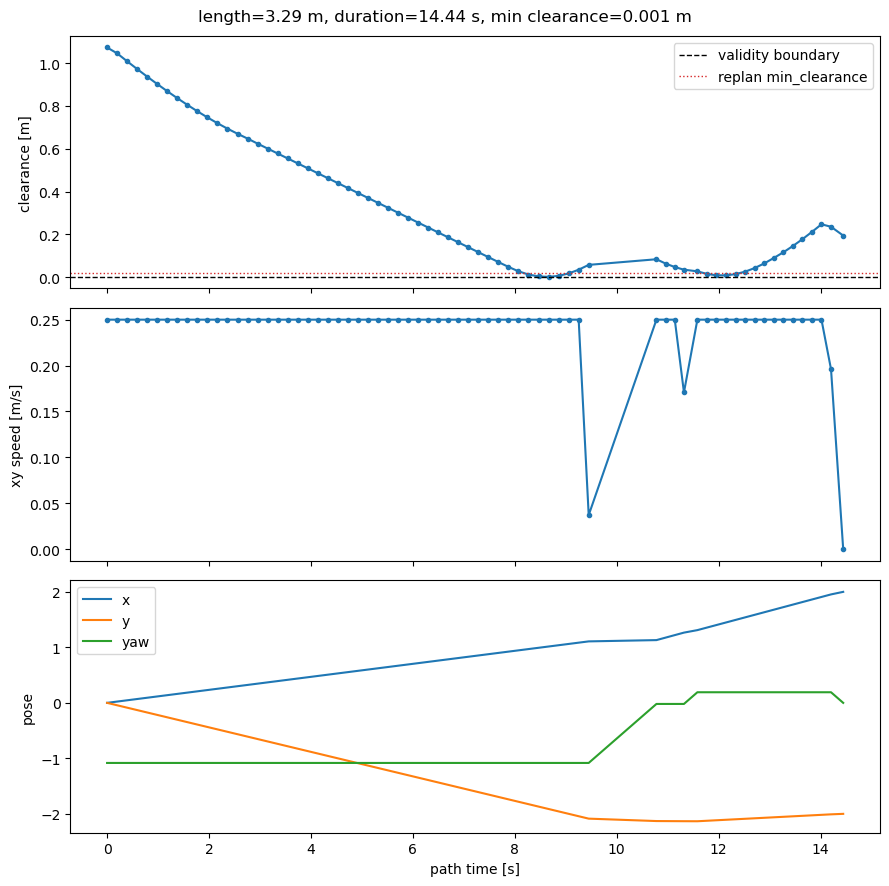

In [353]:
fig, axs = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

axs[0].plot(times, clearances, marker=".")
axs[0].axhline(0.0, color="black", linestyle="--", linewidth=1.0, label="validity boundary")
axs[0].axhline(task_config.get("replan", {}).get("min_clearance", 0.0), color="tab:red", linestyle=":", linewidth=1.0, label="replan min_clearance")
axs[0].set_ylabel("clearance [m]")
axs[0].legend(loc="best")

speed_xy = np.linalg.norm(velocities[:, :2], axis=1)
axs[1].plot(times, speed_xy, marker=".")
axs[1].set_ylabel("xy speed [m/s]")

axs[2].plot(times, path[:, 0], label="x")
axs[2].plot(times, path[:, 1], label="y")
axs[2].plot(times, path[:, 2], label="yaw")
axs[2].set_ylabel("pose")
axs[2].set_xlabel("path time [s]")
axs[2].legend(loc="best")

fig.suptitle(
    f"length={path_length_xy(path):.2f} m, "
    f"duration={times[-1]:.2f} s, "
    f"min clearance={np.nanmin(clearances):.3f} m"
)
fig.tight_layout()
plt.show()

## Compare A Few Goals Or Planner Settings

Use this table to quickly see why some goals are easy and others are narrow. Failed cases are kept in the table instead of stopping the notebook.

In [354]:
CANDIDATE_GOALS = [
    [2.0, -1.0, 0.0],
    [2.0, -1.5, 0.0],
    [2.0, -2.0, 0.0],
]

def summarize_case(goal, planner_name=PLANNER_NAME, d_safe=D_SAFE, solve_time=SOLVE_TIME):
    cfg = copy.deepcopy(task_config)
    cfg["base_pose"] = list(goal)
    cfg["ompl"]["planner"] = planner_name
    cfg["ompl"]["solve_time"] = solve_time
    cfg["esdf"]["d_safe"] = d_safe
    try:
        p, case_path, case_times, _, case_clearances = plan_once(cfg, START)
        return {
            "goal": list(goal),
            "planner": planner_name,
            "d_safe": d_safe,
            "points": len(case_path),
            "length_m": path_length_xy(case_path),
            "duration_s": float(case_times[-1]),
            "min_clearance_m": float(np.nanmin(case_clearances)),
            "p10_clearance_m": float(np.nanpercentile(case_clearances, 10)),
            "status": "ok",
        }
    except Exception as exc:
        return {
            "goal": list(goal),
            "planner": planner_name,
            "d_safe": d_safe,
            "points": 0,
            "length_m": np.nan,
            "duration_s": np.nan,
            "min_clearance_m": np.nan,
            "p10_clearance_m": np.nan,
            "status": str(exc),
        }

rows = [summarize_case(goal) for goal in CANDIDATE_GOALS]
rows

Info:    kBITstar: No optimization objective specified. Defaulting to optimizing path length.
Info:    kBITstar: Searching for a solution to the given planning problem.
Info:    kBITstar (11 iters): Found a solution of cost 3.2211 (3 vertices) from 93 samples by processing 10 edges (9 collision checked) to create 5 vertices and perform 0 rewirings. The graph currently has 5 vertices.
Info:    kBITstar: Pruning disconnected 0 vertices from the tree and completely removed 89 samples.
Info:    kBITstar: Pruning disconnected 0 vertices from the tree and completely removed 84 samples.
Info:    kBITstar: Pruning disconnected 0 vertices from the tree and completely removed 84 samples.
Info:    kBITstar (121 iters): Found a solution of cost 3.1694 (6 vertices) from 393 samples by processing 114 edges (42 collision checked) to create 32 vertices and perform 6 rewirings. The graph currently has 32 vertices.
Info:    kBITstar: Pruning disconnected 0 vertices from the tree and completely removed 9

[{'goal': [2.0, -1.0, 0.0],
  'planner': 'BITstar',
  'd_safe': 0.1,
  'points': 52,
  'length_m': 2.492554963121598,
  'duration_s': 12.081321134954198,
  'min_clearance_m': 0.022077316274432296,
  'p10_clearance_m': 0.029848591972740313,
  'status': 'ok'},
 {'goal': [2.0, -1.5, 0.0],
  'planner': 'BITstar',
  'd_safe': 0.1,
  'points': 62,
  'length_m': 2.956366399588908,
  'duration_s': 14.397034520129354,
  'min_clearance_m': 0.00020450560712367838,
  'p10_clearance_m': 0.004414679445266368,
  'status': 'ok'},
 {'goal': [2.0, -2.0, 0.0],
  'planner': 'BITstar',
  'd_safe': 0.1,
  'points': 68,
  'length_m': 3.2725748089774016,
  'duration_s': 14.496602278198113,
  'min_clearance_m': 0.004206506934156112,
  'p10_clearance_m': 0.020866179442585474,
  'status': 'ok'}]

## Save The Current Path

Run this only when you want to keep the currently planned path for later comparison.

In [355]:
OUT_PATH = ROOT / "tmp/offline_ompl_base_path.npz"
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
np.savez(
    OUT_PATH,
    path=path,
    times=times,
    velocities=velocities,
    clearances=clearances,
    start=START,
    goal=GOAL,
    map_path=str(map_path),
)
OUT_PATH

PosixPath('/home/tueilsy-st-011/repo/mobile_manipulation/tmp/offline_ompl_base_path.npz')